In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data.market_loader import MarketLoader

from src.curves.curve_snapshot import CurveSnapshot
from src.curves.bootstrap.bootstrap_engine import BootstrapCurveEngine
from src.curves.projection_curve import ProjectionCurve
from src.curves.zero_curve import ZeroCurve
from src.curves.simulator.hull_white_2factor import HullWhite2FactorSimulator
from src.curves.simulator.hull_white_2factor_pricer import HullWhite2FactorPricer
from src.curves.calibrator.pca_factor_extractor import PCAFactorExtractor
from src.curves.calibrator.ou_factor_calibrator import OUFactorCalibrator

from src.pricing.hull_white_2factor_swap_pricer import HullWhite2FactorSwapPricer

from src.instruments.instrument_builder import InstrumentBuilder

from src.trades.interest_rate_swap import InterestRateSwap

from src.risk.exposure.stochastic_exposure_engine_2factor import MonteCarloExposureEngine2Factor
from src.risk.exposure.collateralized_exposure_engine import CollateralizedMonteCarloExposureEngine

from src.risk.collateral.csa import CSAAgreement
from src.risk.collateral.netting_set import NettingSet
from src.risk.collateral.mpor_gap_risk import MPORGapRiskEngine

In [2]:
# downloading market curves
market_loader = MarketLoader()
market_curves = market_loader.market_loader_pipeline()

# downloading swap curves
swap_loader = MarketLoader()
swap_curves = swap_loader.swap_loader_pipeline()

treasury curve dataset already downloaded..
sofr curve dataset already downloaded..
futures curve dataset already downloaded..
estr curve dataset already downloaded..
usd_ois curve dataset already downloaded..
eur_ois curve dataset already downloaded..


In [3]:
# yield curve history
curve_history = market_curves['treasury']
curve_history = curve_history / 100

In [ ]:
### create curve snapshots
# SOFR snapshot
sofr_df = market_curves['sofr']

latest_date = sofr_df.index[-1]
latest_sofr_curve = sofr_df.iloc[-1]

sofr_snapshot = CurveSnapshot.snap_from_df_row(
    curve_name = 'sofr',
    as_of_date = latest_date,
    curve_row = latest_sofr_curve
)

# Futures snapshot
future_df = market_curves['futures']
latest_futures_curve = future_df.iloc[-1]

futures_snapshot = CurveSnapshot.snap_from_df_row(
    curve_name = 'futures',
    as_of_date = latest_date,
    curve_row = latest_futures_curve
)

# OIS snapshot
ois_df = swap_curves['usd_ois']

latest_swap_date = ois_df.index[-1]
latest_swap_curve = ois_df.iloc[-1]

ois_snapshot = CurveSnapshot.snap_from_df_row(
    curve_name = 'usd_ois',
    as_of_date = latest_swap_date,
    curve_row = latest_swap_curve
)

In [5]:
### create instruments from curve snapshot
# deposits
deposit_instruments = InstrumentBuilder.build_deposit_instruments(snapshot = sofr_snapshot)

# futures
future_instruments = InstrumentBuilder.build_future_instruments(snapshot = futures_snapshot)

# ois
ois_instruments = InstrumentBuilder.build_ois_instruments(snapshot = ois_snapshot)

### discount, projection and zero curve builder
# bootstrapping engine for generating the discount curve
all_instruments = deposit_instruments + future_instruments + ois_instruments

engine = BootstrapCurveEngine()

discount_curve = engine.bootstrap(
    snapshot = sofr_snapshot,
    instruments = all_instruments
)

# projection curve
projection_curve = ProjectionCurve(discount_curve = discount_curve)

# zero curve
zero_curve = ZeroCurve(discount_curve = discount_curve)

In [6]:
# sample IRS trade objects
IR_swap1 = InterestRateSwap(
    notional = 1_000_000,
    maturity = 3.0,
    fixed_rate = 3.40,
    pay_fixed = True
)

IR_swap2 = InterestRateSwap(
    notional = 2_500_000,
    maturity = 5.0,
    fixed_rate = 3.75,
    pay_fixed = False
)

IR_swap3 = InterestRateSwap(
    notional = 1_500_000,
    maturity = 2.0,
    fixed_rate = 3.25,
    pay_fixed = True
)

In [7]:
### PCA factor extractor
# initialize PCA factor extractor
pca = PCAFactorExtractor(n_factors = 2)

# fitting PCAs to historical yield changes and projecting onto factors
factor_history = pca.fit_transform(yield_curve_history = curve_history)

In [8]:
# Ornstein-Uhlenbeck factor calibration
ou_calibrator = OUFactorCalibrator(dt = 1/252)

# calibrate HW 2-factor model parameters
hw2f_params = ou_calibrator.calibrate_hw2f(factor_history = factor_history)
hw2f_params

{'a': 0.0994245389493929,
 'b': 0.06493166163063027,
 'sigma1': 0.018724138829696178,
 'sigma2': 0.008874071471247505,
 'rho': -0.0006194015774373465}

In [9]:
### HW 2-factor simulator using calibrated HW 2-factor model parameters
# short rate
r0 = zero_curve.get_zero_rate(maturity = 0.25)

# simulator engine
hw_simulator = HullWhite2FactorSimulator(
    r0 = r0,
    a = hw2f_params['a'],
    b = hw2f_params['b'],
    sigma1 = hw2f_params['sigma1'],
    sigma2 = hw2f_params['sigma2'],
    rho = hw2f_params['rho'],
    random_seed = 2
)

# hw pricer
hw_pricer = HullWhite2FactorPricer(
    zero_curve = zero_curve,
    a = hw2f_params['a'],
    b = hw2f_params['b'],
    sigma1 = hw2f_params['sigma1'],
    sigma2 = hw2f_params['sigma2'],
    rho = hw2f_params['rho']
)

# hw 2-factor swap pricer
hw_swap_pricer = HullWhite2FactorSwapPricer(hw_pricer = hw_pricer)

# exposure engine
hw2f_trade_engine = MonteCarloExposureEngine2Factor(
    pricer = hw_swap_pricer,
    simulator = hw_simulator
)

In [10]:
### Collateralization framework
# CSA agreement
H = 150_000
MTA = 25_000
IA = 100_000
MPOR = 10
trade_list = [
    IR_swap1,
    IR_swap2,
    IR_swap3
]

csa = CSAAgreement(
    threshold = H,
    minimum_transfer_amount = MTA,
    independent_amount = IA,
    margin_period_of_risk = MPOR
)

print(csa.summary())

# netting set
netting_set = NettingSet(
    trades = trade_list,
    csa_agreement = csa,
    netting_id = 'USD_IRS_portfolio_1'
)

display(netting_set.summary())

# collateralized engine
collateral_engine = CollateralizedMonteCarloExposureEngine(
    trade_exposure_engine = hw2f_trade_engine,
    netting_engine = netting_set
)

# MPOR engine
mpor_engine = MPORGapRiskEngine(
    exposure_engine = hw2f_trade_engine,
    netting_engine = netting_set
)

{'Threshold': 150000, 'MTA': 25000, 'IndependentAmount': 100000, 'MPOR_Days': 10}


,NettingID,Trades,CSAEnabled
0,USD_IRS_portfolio_1,3,True


In [11]:
### trade-level simulations -> portfolio-level uncollateralized expected exposure
simulation_paths = 250
trading_days = 252

def pad_matrix(pv_matrix, pad_width):
    """ Aligning pv_matrices with different trade maturities to the same cashflow grid length """
    _n_paths, n_times = pv_matrix.shape

    if n_times == pad_width:
        return pv_matrix
    
    padding = np.zeros((_n_paths, pad_width - n_times))

    return np.hstack([pv_matrix, padding])

# compute pv matrices for each trade
pv_1 = hw2f_trade_engine.simulate_pv_matrix(
    swap = IR_swap1,
    n_paths = simulation_paths,
    steps_per_year = trading_days
)

pv_2 = hw2f_trade_engine.simulate_pv_matrix(
    swap = IR_swap2,
    n_paths = simulation_paths,
    steps_per_year = trading_days
)

pv_3 = hw2f_trade_engine.simulate_pv_matrix(
    swap = IR_swap3,
    n_paths = simulation_paths,
    steps_per_year = trading_days
)

# align cashflow grids for individual trades at portfolio-level
max_times = max(
    pv_1.shape[1],
    pv_2.shape[1],
    pv_3.shape[1]
)

pv_1 = pad_matrix(
    pv_matrix = pv_1, 
    pad_width = max_times
)

pv_2 = pad_matrix(
    pv_matrix = pv_2, 
    pad_width = max_times
)

pv_3 = pad_matrix(
    pv_matrix = pv_3, 
    pad_width = max_times
)

# aggregate future values
uncollateralized_net = pv_1 + pv_2 + pv_3

# uncollateralized expected exposure at portfolio-level
uncollateralized_ee = np.maximum(uncollateralized_net, 0).mean(axis = 0)
uncollateralized_ee

array([36995.45988891, 37882.08890001, 37582.52810177, ...,
         322.81980066,   162.24467099,     0.        ], shape=(1261,))

In [12]:
### collateralized expected exposure
collateralized_ee = collateral_engine.expected_exposure(
    n_paths = 250,
    steps_per_year = trading_days
)
collateralized_ee

,Times,CollateralizedEE
0,0.000000,0.000000
1,0.003968,0.000000
2,0.007937,0.000000
3,0.011905,2.350783
4,0.015873,130.534629
...,...,...
1256,4.984127,0.000000
1257,4.988095,0.000000
1258,4.992063,0.000000
1259,4.996032,0.000000


In [13]:
### MPOR expected exposure
mpor_ee = mpor_engine.expected_gap_exposure(
    n_paths = 250
)
mpor_ee

,Times,EE_MPOR
0,0.000000,1118.815834
1,0.003968,1928.201208
2,0.007937,2064.481202
3,0.011905,2399.266743
4,0.015873,2915.665701
...,...,...
1256,4.984127,0.000000
1257,4.988095,0.000000
1258,4.992063,0.000000
1259,4.996032,0.000000


In [14]:
### MPOR potential future exposure
percentile = 95.0
mpor_pfe = mpor_engine.potential_future_gap_exposure(
    percentile = percentile,
    n_paths = 250
)

mpor_pfe

,Times,PFE_95%
0,0.000000,1667.946647
1,0.003968,6493.408971
2,0.007937,12788.396866
3,0.011905,24361.240248
4,0.015873,30938.464988
...,...,...
1256,4.984127,0.000000
1257,4.988095,0.000000
1258,4.992063,0.000000
1259,4.996032,0.000000


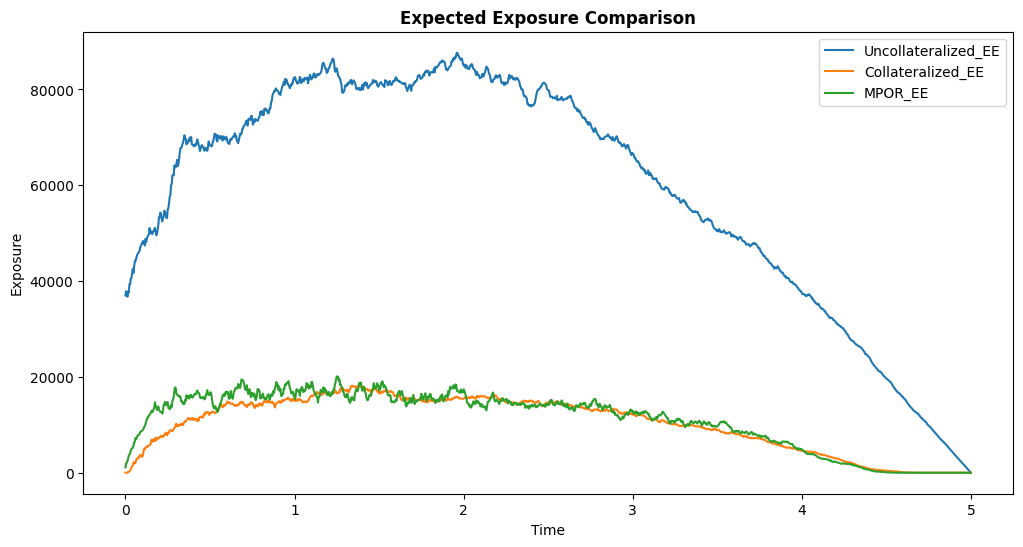

In [15]:
# plot expected exposure comparisons
plt.figure(figsize = (12, 6))

plt.plot(collateralized_ee['Times'], uncollateralized_ee, label = 'Uncollateralized_EE')
plt.plot(collateralized_ee['Times'], collateralized_ee['CollateralizedEE'], label = 'Collateralized_EE')
plt.plot(mpor_ee['Times'], mpor_ee['EE_MPOR'], label = 'MPOR_EE')

plt.title('Expected Exposure Comparison', fontweight = 'bold')
plt.xlabel('Time')
plt.ylabel('Exposure')
plt.legend(loc = 'best')
plt.show()

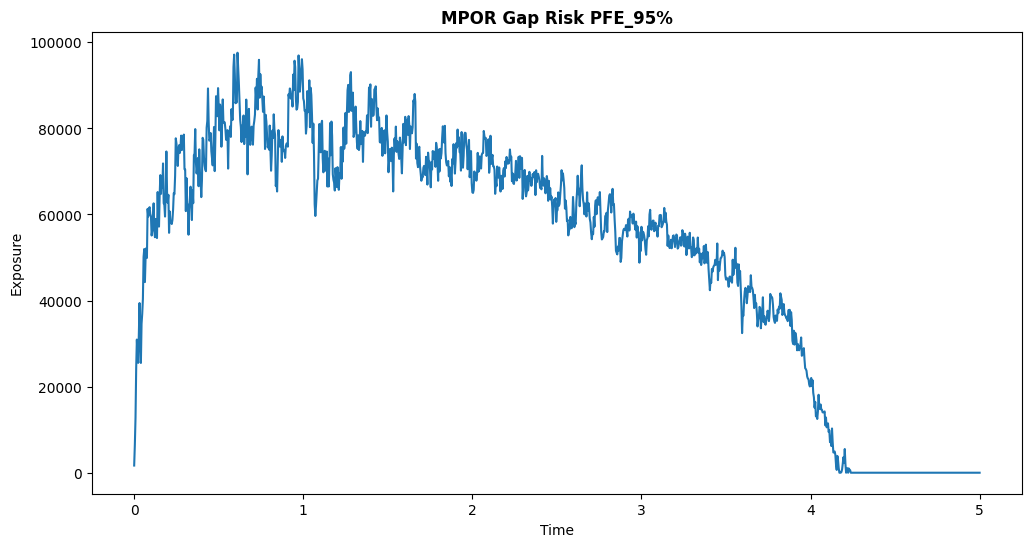

In [16]:
# plot MPOR potential future exposure profile
plt.figure(figsize = (12, 6))

plt.plot(mpor_pfe['Times'], mpor_pfe[f'PFE_{percentile:.0f}%'])

plt.title(f'MPOR Gap Risk PFE_{percentile:.0f}%', fontweight = 'bold')
plt.xlabel('Time')
plt.ylabel('Exposure')
plt.show()